# Лабораторная работа № 3.2 — Натуральный кубический сплайн

Вариант 6. 

Строим отдельный кубический многочлен между каждыми соседними узлами. Сплайн проходит через таблицу и имеет нулевую кривизну на концах.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[-2.0, -1.0, 0.0, 1.0, 2.0], [0.13534, 0.36788, 1.0, 2.7183, 7.3891], [-0.5]]
xs, ys, x_star = rows[0], rows[1], rows[2][0]
print('Узлы:', xs, '\nЗначения:', ys, '\nx* =', x_star)

Узлы: [-2.0, -1.0, 0.0, 1.0, 2.0] 
Значения: [0.13534, 0.36788, 1.0, 2.7183, 7.3891] 
x* = -0.5


## Прогонка для коэффициентов

Условия гладкости дают трёхдиагональную систему для коэффициентов c. После прогонки вычисляются a, b и d.

In [2]:
def tri_diagonal_matrix_algorithm(matrix: list, d: list, shape: int) -> list:
    a, b, c = zip(*matrix)
    p = [-c[0] / b[0]]
    q = [d[0] / b[0]]
    x = [0] * (shape + 1)
    for i in range(1, shape):
        p.append(-c[i] / (b[i] + a[i] * p[i - 1]))
        q.append((d[i] - a[i] * q[i - 1]) / (b[i] + a[i] * p[i - 1]))

    for i in reversed(range(shape)):
        x[i] = p[i] * x[i + 1] + q[i]

    return x[:-1]


def spline(x: list, f: list) -> List[list]:
    n = len(x)
    h = [x[i] - x[i - 1] for i in range(1, n)]
    tridiag_matrix = [[0, 2 * (h[0] + h[1]), h[1]]]
    b = [3 * ((f[2] - f[1]) / h[1] - (f[1] - f[0]) / h[0])]
    for i in range(1, n - 3):
        tridiag_row = [h[i], 2 * (h[i] + h[i + 1]), h[i + 1]]
        tridiag_matrix.append(tridiag_row)
        b.append(3 * ((f[i + 2] - f[i + 1]) / h[i + 1] - (f[i + 1] - f[i]) / h[i]))

    tridiag_matrix.append([h[-2], 2 * (h[-2] + h[-1]), 0])
    b.append(3 * ((f[-1] - f[-2]) / h[-1] - (f[-2] - f[-3]) / h[-2]))

    c = tri_diagonal_matrix_algorithm(tridiag_matrix, b, n - 2)
    a = []
    b = []
    d = []
    c.insert(0, 0)
    for i in range(1, n):
        a.append(f[i - 1])
        if i < n - 1:
            d.append((c[i] - c[i - 1]) / (3 * h[i - 1]))
            b.append((f[i] - f[i - 1]) / h[i - 1] - h[i - 1] * (c[i] + 2 * c[i - 1]) / 3)

    b.append((f[-1] - f[-2]) / h[-1] - 2 * h[-1] * c[-1] / 3)
    d.append(-c[-1] / (3 * h[-1]))
    return a, b, c, d


def interpolate(x: list, x_0: float, coef: list) -> float:
    k = 0
    for i, j in zip(x, x[1:]):
        if i <= x_0 <= j:
            break
        k += 1
    
    a, b, c, d = coef
    diff = x_0 - x[k]
    return a[k] + b[k] * diff + c[k] * diff ** 2 + d[k] * diff ** 3

In [3]:
a, b, c_coef, d = spline(xs, ys)
value = interpolate(xs, x_star, (a, b, c_coef, d))
print('S(x*) =', value)
for i in range(len(a)):
    print(f'[{xs[i]}, {xs[i+1]}]: a={a[i]:.6f}, b={b[i]:.6f}, c={c_coef[i]:.6f}, d={d[i]:.6f}')

S(x*) = 0.6265379464285714
[-2.0, -1.0]: a=0.135340, b=0.150371, c=0.000000, d=0.082169
[-1.0, 0.0]: a=0.367880, b=0.396879, c=0.246508, d=-0.011266
[0.0, 1.0]: a=1.000000, b=0.856095, c=0.212709, d=0.649496
[1.0, 2.0]: a=2.718300, b=3.230001, c=2.161198, d=-0.720399


## График

График показывает результат вычисления на тех же исходных данных.

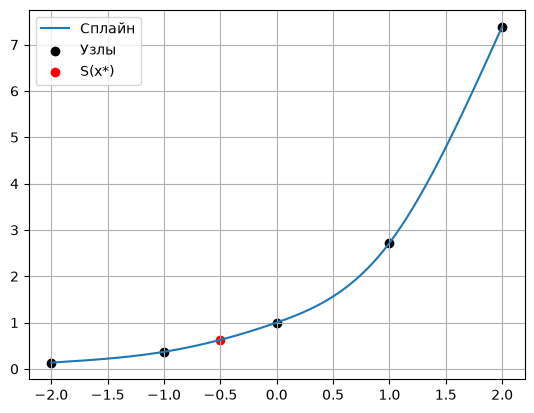

In [4]:
coefs = (a, b, c_coef, d)
grid = np.linspace(xs[0], xs[-1], 400)
plt.plot(grid, [interpolate(xs, t, coefs) for t in grid], label='Сплайн')
plt.scatter(xs, ys, color='black', label='Узлы')
plt.scatter([x_star], [value], color='red', label='S(x*)')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Проверь, что сплайн проходит через все узлы и что кривизна на концах равна нулю.

In [5]:
coefs = (a, b, c_coef, d)
assert np.allclose([interpolate(xs, t, coefs) for t in xs], ys, atol=1e-10)
assert abs(c_coef[0]) < 1e-12
assert abs(c_coef[-1] + 3*d[-1]*(xs[-1]-xs[-2])) < 1e-12
print('Проверка узлов и граничных условий пройдена')

Проверка узлов и граничных условий пройдена
